<a href="https://colab.research.google.com/github/nerdycore/Thesis_Project/blob/main/mobilenet_with_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile

# Path to your ZIP file in Drive
zip_path = '/content/drive/MyDrive/Thesis/Dataset/MangoFruit&Leaf.zip'  # Adjust if needed

# Extract to local VM storage
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Extraction complete!")

Extraction complete!


In [ ]:

import time
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import imageio.v2 as io
from skimage.transform import resize
import pathlib
import json



In [ ]:
# data loading
data_dir = pathlib.Path("/content/dataset/MangoFruit&Leaf")
image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}

mango_disease_dict = {
    "alternaria_fruit": [f for f in data_dir.glob("Alternaria_Fruit/*") if f.suffix.lower() in image_extensions],
    "anthracnose_fruit": [f for f in data_dir.glob("Anthracnose_Fruit/*") if f.suffix.lower() in image_extensions],
    'mango_scab_fruit': [f for f in data_dir.glob("MangoScab_Fruit/*") if f.suffix.lower() in image_extensions],
    "stem_end_rot_fruit": [f for f in data_dir.glob("StemEndrot_Fruit/*") if f.suffix.lower() in image_extensions],
    'healthy_fruit': [f for f in data_dir.glob("Healthy_Fruit/*") if f.suffix.lower() in image_extensions],
    "anthracnose_leaf": [f for f in data_dir.glob("Anthracnose_Leaf/*") if f.suffix.lower() in image_extensions],
    'powdery_mildew_leaf': [f for f in data_dir.glob("PowderyMildew_Leaf/*") if f.suffix.lower() in image_extensions],
    "scooty_mould_leaf": [f for f in data_dir.glob("ScootyMould_Leaf/*") if f.suffix.lower() in image_extensions],
    'healthy_leaf': [f for f in data_dir.glob("Healthy_Leaf/*") if f.suffix.lower() in image_extensions],
}

mango_disease_labels = {
    'alternaria_fruit' : 0, 'anthracnose_fruit': 1, 'mango_scab_fruit': 2,
    "stem_end_rot_fruit": 3, 'healthy_fruit': 4,
    "anthracnose_leaf": 5, 'powdery_mildew_leaf': 6, "scooty_mould_leaf": 7,
    "healthy_leaf": 8
}

In [ ]:
# Load images
x, y = [], []
for disease, images in mango_disease_dict.items():
    for image in images:
        img = io.imread(image)
        resized_img = resize(img, (224, 224), preserve_range=True)
        resized_image = preprocess_input(resized_img.astype(np.float32))
        x.append(resized_image)
        y.append(mango_disease_labels[disease])

x = np.array(x, dtype=np.float32)
y = np.array(y)



Train: 1728, Val: 432, Test: 540


In [ ]:
# Split data
x_trainval, x_test, y_trainval, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)
x_train, x_val, y_train, y_val = train_test_split(
    x_trainval, y_trainval, test_size=0.2, random_state=42, stratify=y_trainval
)

print(f"Train: {len(x_train)}, Val: {len(x_val)}, Test: {len(x_test)}")

In [ ]:

# Build MobileNet Model

base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze for feature extraction

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
outputs = Dense(9, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# Save model architecture
with open('mobilenet_summary.txt', 'w') as f:
    model.summary(print_fn=lambda x: f.write(x + '\n'))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,428,745 (9.26 MB)

 Trainable params: 167,945 (656.04 KB)

 Non-trainable params: 2,260,800 (8.62 MB)

In [ ]:
# Train with Benchmarking (No Early Stopping)

from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train, num_classes=9)
y_val_cat = to_categorical(y_val, num_classes=9)
y_test_cat = to_categorical(y_test, num_classes=9)


checkpoint = ModelCheckpoint('mobilenet_best.keras', monitor='val_accuracy', save_best_only=True)


start_time = time.time()

history = model.fit(
    x_train, y_train_cat,
    validation_data=(x_val, y_val_cat),
    epochs=300,
    batch_size=32,
    callbacks=[checkpoint],
    verbose=1
)

train_time = time.time() - start_time
print(f"Total training time: {train_time/60:.2f} minutes")

Epoch 1/300
54/54 ━━━━━━━━━━━━━━━━━━━━ 44s 386ms/step - accuracy: 0.7014 - loss: 0.8530 - val_accuracy: 0.7870 - val_loss: 0.5374
Epoch 2/300
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.8275 - loss: 0.4044 - val_accuracy: 0.8009 - val_loss: 0.4129
Epoch 3/300
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.8623 - loss: 0.3362 - val_accuracy: 0.7917 - val_loss: 0.3860
Epoch 4/300
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.8727 - loss: 0.2822 - val_accuracy: 0.7894 - val_loss: 0.3842
Epoch 5/300
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.8646 - loss: 0.2948 - val_accuracy: 0.8009 - val_loss: 0.3775
Epoch 6/300
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.8733 - loss: 0.2553 - val_accuracy: 0.7778 - val_loss: 0.3871
Epoch 7/300
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.8837 - loss: 0.2229 - val_accuracy: 0.7894 - val_loss: 0.4069
Epoch 8/300
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.8854 - loss: 0.2238 - val_accuracy: 

In [ ]:

# extract metrics

def extract_metrics(history):
    """Extract best epoch and accuracies from history"""
    val_acc = history.history['val_accuracy']
    train_acc = history.history['accuracy']
    best_epoch = np.argmax(val_acc) + 1
    best_val_acc = val_acc[best_epoch - 1]
    best_train_acc = train_acc[best_epoch - 1]

    # Find convergence (where val_acc doesn't improve much)
    # Simple: first epoch where val_acc > 0.85
    converge_epoch = None
    for i, acc in enumerate(val_acc):
        if acc > 0.85:
            converge_epoch = i + 1
            break

    return {
        'best_epoch': best_epoch,
        'best_train_acc': best_train_acc,
        'best_val_acc': best_val_acc,
        'converge_epoch': converge_epoch,
        'total_epochs': len(val_acc)
    }

metrics = extract_metrics(history)
print(f"\n=== MobileNet Results ===")
print(f"Best epoch: {metrics['best_epoch']}")
print(f"Best val accuracy: {metrics['best_val_acc']:.4f}")
print(f"Converged at epoch: {metrics['converge_epoch']}")

# Load best model and evaluate test
model.load_weights('mobilenet_best.keras')
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)
metrics['test_acc'] = test_acc
print(f"Test accuracy: {test_acc:.4f}")



=== MobileNet Results ===
Best epoch: 12
Best val accuracy: 0.8079
Converged at epoch: None
Test accuracy: 0.8111


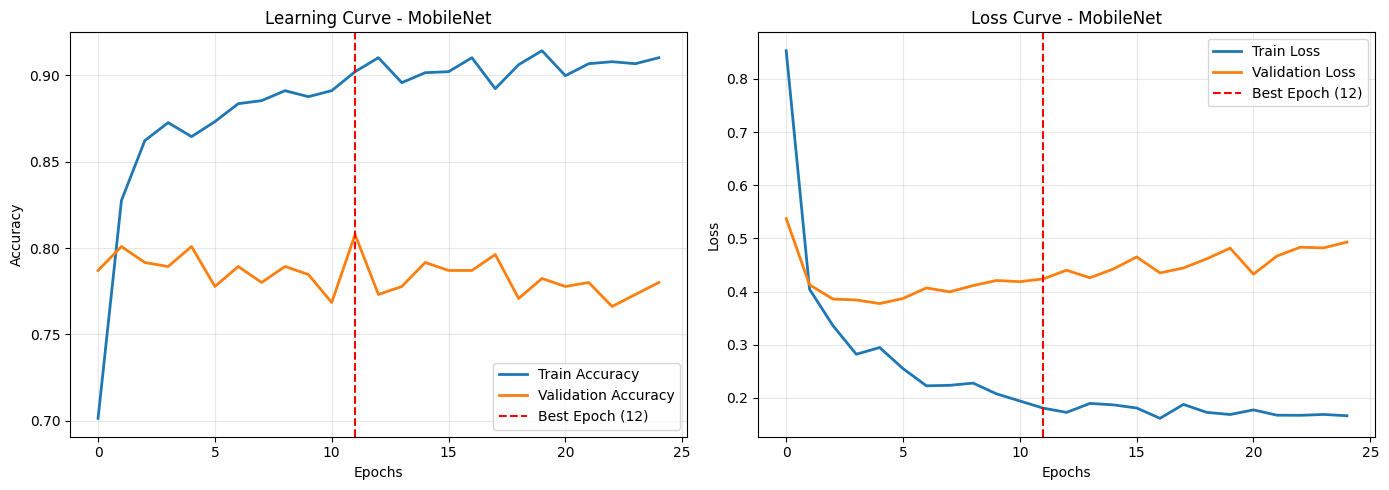

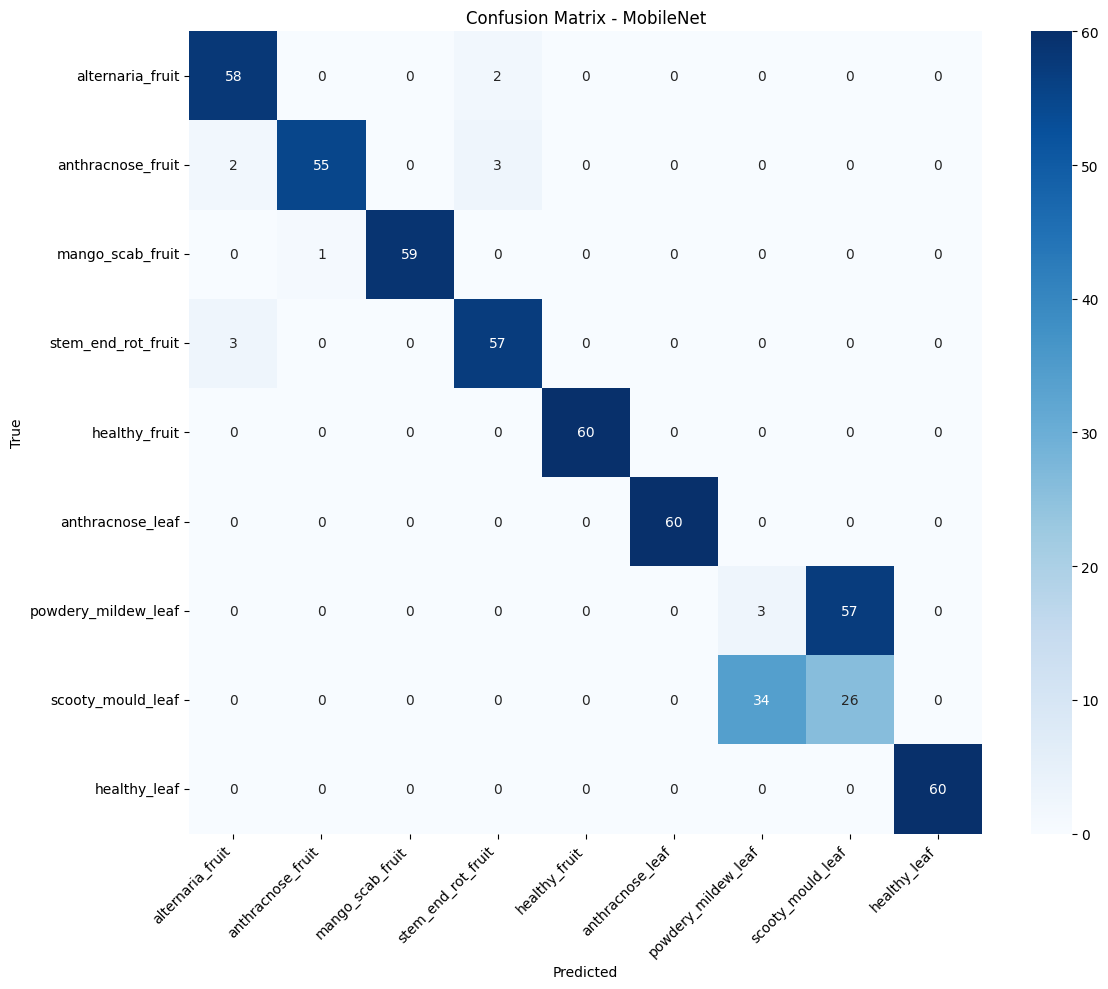


Results saved to 'mobilenet_summary.csv'


In [ ]:
# ----------------------------
# 5. Per-class Metrics
# ----------------------------
y_pred = model.predict(x_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
class_report = classification_report(y_test, y_pred_classes, output_dict=True)
metrics['class_report'] = class_report

import json
import numpy as np

def convert_to_serializable(obj):
    """Recursively convert numpy types to Python native types."""
    if isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_serializable(v) for v in obj]
    else:
        return obj

# Apply conversion before saving
metrics_serializable = convert_to_serializable(metrics)

# Now save
with open('mobilenet_metrics.json', 'w') as f:
    json.dump(metrics_serializable, f, indent=2)
# ----------------------------
# 6. Visualizations
# ----------------------------
# Learning Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].axvline(x=metrics['best_epoch']-1, color='red', linestyle='--', label=f'Best Epoch ({metrics["best_epoch"]})')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Learning Curve - MobileNet')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].axvline(x=metrics['best_epoch']-1, color='red', linestyle='--', label=f'Best Epoch ({metrics["best_epoch"]})')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss Curve - MobileNet')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mobilenet_learning_curves.png', dpi=300)
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)
class_names = list(mango_disease_labels.keys())

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - MobileNet')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('mobilenet_confusion_matrix.png', dpi=300)
plt.show()

# ----------------------------
# 7. Save All Results
# ----------------------------
# Summary table
summary = pd.DataFrame({
    'Metric': ['Best Epoch', 'Best Val Accuracy', 'Test Accuracy', 'Total Training Time (min)'],
    'Value': [
        metrics['best_epoch'],
        f"{metrics['best_val_acc']:.4f}",
        f"{metrics['test_acc']:.4f}",
        f"{train_time/60:.2f}"
    ]
})
summary.to_csv('mobilenet_summary.csv', index=False)
print("\nResults saved to 'mobilenet_summary.csv'")